## Introducción a PyTorch

PyTorch es un framework de aprendizaje profundo desarrollado por Facebook, de **código abierto** y con contribuciones de miles de usuarios. Es una alternativa a otros frameworks como TensorFlow o MXNet. El lenguaje de programación utilizado por este framework es Python (aunque muchas de sus partes están programas en otros lenguajes como C++). En este tutorial, vamos a aprender los fundamentos de PyTorch para que puedas utilizarlo en el resto de prácticas.



#### Primeros pasos
Lo primero consiste en ver si tenemos PyTorch instalado y conocer su versión:

In [1]:
import torch
print(torch.__version__)

2.11.0+cu128


si en la salida anterior ves **cpu** será que estás ejecutando una compilación de PyTorch solo con soporte para CPU y no GPU. Si por el contrario quieres ejecutar PyTorch en una máquina con GPU como Google Colab (o incluso tu propia máquina con GPU y Cuda instalado), la salida de este comando debería indicartelo. Ten en cuenta que la versión con GPU también soporta entrenamientos en la CPU (lo contrario no es cierto).

Un aspecto importante en los experimentos que hagamos será la reproducibilidad de resultados. Establecemos una semilla para que todos los números aleatorios generados sean los mismos ejecución tras ejecución:

In [2]:
torch.manual_seed(2032)

In [22]:
import numpy as np
import matplotlib.pyplot as plt

#### Tensores

Los tensores son la pieza clave en cualquier framework de aprendizaje profundo. Son equivalentes a los arrays de Numpy pero tienen ciertas diferencias muy importantes:

1. Los tensores **pueden moverse entre diferentes dispositivos**. Es decir, podemos tener un tensor en CPU y moverlo a la GPU y todos los cálculos realizados con este pasarán a realizarse en este dispositivo.
2. Los tensores están preparados para diferenciar sobre ellos (calcular las derivadas parciales necesarias para aplicar descenso de gradiente).

De todas maneras, una de las principales ventajas de PyTorch es que si sabemos operar con arrays de Numpy, cambiar a hacerlo con tensores será muy sencillo. Vamos a crear nuestro primer Tensor:

In [3]:
x = torch.Tensor(3, 4)
print(x)

tensor([[ 7.6244e-34,  4.4106e-41,  7.6244e-34,  4.4106e-41],
        [-2.7500e+06,  4.4103e-41, -2.8541e+06,  4.4103e-41],
        [-2.9556e+06,  4.4103e-41, -2.9556e+06,  4.4103e-41]])


aquí tenemos un tensor de 3x4 de números reales, inicializado con los valores que estén en memoria en ese momento.

Podemos mostrar su dimensión:

In [4]:
print(x.shape)

torch.Size([3, 4])


También es posible inicializar tensores con otros valores, como por ejemplo, ceros, unos o valores aleatorios entre 0 y 1:

In [5]:
print(torch.zeros(3,4))
print(torch.ones(3,4))
print(torch.rand(3,4))

tensor([[0., 0., 0., 0.],
        [0., 0., 0., 0.],
        [0., 0., 0., 0.]])
tensor([[1., 1., 1., 1.],
        [1., 1., 1., 1.],
        [1., 1., 1., 1.]])
tensor([[0.6282, 0.7710, 0.5404, 0.5480],
        [0.0920, 0.3038, 0.9887, 0.5169],
        [0.7733, 0.7820, 0.8844, 0.8440]])


Otra manera de crear un tensor es hacerlo desde un array de numpy existente:

In [6]:
import numpy as np
np_arr = np.array([[1, 2], [3, 4]])
tensor = torch.from_numpy(np_arr)
print(tensor)
print(tensor.shape)

tensor([[1, 2],
        [3, 4]])
torch.Size([2, 2])


En este case se pude ver que como el array era de números enteros, el tensor resultante mantiene este tipo. Siempre podemos ver el **tipo de los elementos de un tensor** con la siguiente instrucción:

In [7]:
print(tensor.dtype)

torch.int64


Ten en cuenta que **el tipo es crítico** ya que nuestra red va a requerir muchísimos parámetros que al final van a ser tensores y la memoria de nuestros dispositivos es limitada. Te recomiendo el siguiente [enlace](https://pytorch.org/docs/stable/tensors.html) para conocer los diferentes tipos y saber cuando ocupa cada uno en memoria.

Además de crear tensores, muchas veces es interesante convertirlos de vuelta a Numpy. Podemos hacerlo de la siguiente manera:

In [8]:
tensor.cpu().numpy()

array([[1, 2],
       [3, 4]])

Ten en cuenta que la llamada cpu() lo que hace es mover el tensor a la cpu (si no está ya). Es importante hacer esta llamada porque para pasar el tensor a numpy tiene que estar en cpu primero.

Para mover tensores de un dispositivo a otro podemos hacerlo de la siguiente manera.

In [9]:
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
tensor = tensor.to(device)

obviamente para que esto funcione debemos tener PyTorch instalado con soporte para cuda (sino el tensor se quedará en la cpu). En este caso **cuda:0** indica que queremos mover el tensor a la primera GPU del sistema. Es importante tener en cuenta que `tensor.to` devuelve el tensor en el nuevo dispositivo por tanto debemos recordar guardarlo en una variable para posteriormente poder usarlo.

#### Operaciones con tensores

Existen multitud de operaciones que se pueden realizar con tensores. En el siguiente [enlace](https://pytorch.org/docs/stable/tensors.html#) tienes una descripción completa de todas las operaciones que se pueden realizar. Aquí vamos a describir las más básicas.

In [10]:
t1 = torch.rand(3,2)
t2 = torch.rand(3,2)
suma = t1+t2
print(t1)
print(t2)
print(suma)

tensor([[0.6985, 0.2108],
        [0.1112, 0.1474],
        [0.8116, 0.1859]])
tensor([[0.5345, 0.4596],
        [0.3705, 0.5302],
        [0.5715, 0.7342]])
tensor([[1.2330, 0.6704],
        [0.4817, 0.6776],
        [1.3831, 0.9201]])


ten en cuenta que esta operación crea un nuevo tensor en memoria. En PyTorch es posible también realizar **operaciones sobre los mismos tensores**, para no gastar espacio extra en memoria. Por ejemplo:

In [11]:
t2.add_(t1)

tensor([[1.2330, 0.6704],
        [0.4817, 0.6776],
        [1.3831, 0.9201]])

Tenemos otras operaciones disponibles pero en general, **las operaciones básicas que puedes hacer con Numpy también se pueden hacer con tensores**:

In [12]:
t1 = torch.rand(3,2)
t2 = torch.rand(3,2)
print(t1)
print(t2)
print("Resta:")
print(t1-t2)
print("Multiplicación por un escalar:")
print(t1*3)
print("Multiplicación de matrices elemento a elemento:")
print(t1*t2)
print("Multiplicación de matrices normal:")
#Importante: estamos haciendo la transpuesta de t2 para poder multiplicarlas y que coincidan las dimesiones
print(t1@t2.T)

tensor([[0.4333, 0.4734],
        [0.1678, 0.0093],
        [0.9842, 0.3493]])
tensor([[0.5617, 0.6045],
        [0.8110, 0.5253],
        [0.3047, 0.6035]])
Resta:
tensor([[-0.1284, -0.1311],
        [-0.6432, -0.5160],
        [ 0.6795, -0.2542]])
Multiplicación por un escalar:
tensor([[1.2999, 1.4201],
        [0.5034, 0.0278],
        [2.9526, 1.0479]])
Multiplicación de matrices elemento a elemento:
tensor([[0.2434, 0.2861],
        [0.1361, 0.0049],
        [0.2999, 0.2108]])
Multiplicación de matrices normal:
tensor([[0.5295, 0.6001, 0.4177],
        [0.0999, 0.1410, 0.0567],
        [0.7640, 0.9817, 0.5107]])


#### Cambio de la forma de un tensor

En muchas ocasiones necesitamos cambiar la forma de un tensor, para luego poder operar con él correctamente. Para esto es muy adecuada la función **view**:

In [13]:
#arange crea un tensor con valores desde 0 hasta n-1
t1 = torch.arange(10)
print(t1)

#digamos que queremos una matriz de 5x2
print(t1.view(5,2))

#También podemos inferir dimensiones
print(t1.view(5,-1))

tensor([0, 1, 2, 3, 4, 5, 6, 7, 8, 9])
tensor([[0, 1],
        [2, 3],
        [4, 5],
        [6, 7],
        [8, 9]])
tensor([[0, 1],
        [2, 3],
        [4, 5],
        [6, 7],
        [8, 9]])


es interesante entender que view devuelve un nuevo tensor pero que comparte la estructura interna con el tensor original, es decir, no estamos almacenando los datos de nuevo, sino simplemente **dándoles otra forma**.

#### Indexado
El indexado funciona de igual manera que en Numpy. Veamos algunos ejemplos:

In [14]:
t1 = torch.arange(12).view(3,4)
print(t1)

print("Solo la segunda fila (empieza a contar en cero):")
print(t1[1,:])
print("Solo la última columna:")
print(t1[:,-1])
print("Seleccionar el primer elemento de las dos primeras filas:")
print(t1[:2,0])

tensor([[ 0,  1,  2,  3],
        [ 4,  5,  6,  7],
        [ 8,  9, 10, 11]])
Solo la segunda fila (empieza a contar en cero):
tensor([4, 5, 6, 7])
Solo la última columna:
tensor([ 3,  7, 11])
Seleccionar el primer elemento de las dos primeras filas:
tensor([0, 4])


### Ejercicios propuestos
1. Navega por la documentación de PyTorch (https://pytorch.org/docs/stable/torch.html) y busca un par de funciones interesantes para operar con tensores que no aparezcan en este notebook.
2. Ejecuta el notebook en Google Colab. Cambia el tipo de dispositivo de tu máquina y trata de ejecutar el código anterior en diferentes dispositivos. Usa el atributo del tensor `device` para conocer en que dispositivo se encuentra.
3. Intenta realizar una operación con dos tensores que se encuentren en dispositivos diferentes. ¿Qué sucede en este caso?
4. Ejecuta el notebook en local, comprueba que todos los tensores están en la CPU.
5. Implementa un perceptrón utilizando tensores en PyTorch. Comprueba que su salida ante una entrada concreta es correcta.
6. Realiza las siguientes operaciones con tensores:
   - Crear Tensores: Crea los siguientes tensores en PyTorch:
      - Un tensor *t_1* de 10 elementos igualmente espaciados entre 0 y 1.
      - Un tensor *t_2* de tamaño 3x3 con valores aleatorios.
      - Un tensor *t_3* de tamaño 2x3x4 con todos sus elementos inicializados a 1.
   - Extrae la segunda fila del tensor *t_2*.
   - Cambia la forma (reshape) de *t_3* a un tensor 2D de tamaño 6x4.
   - Transpón el tensor *t_2* (intercambia filas por columnas).
   - Suma el tensor [1.0, 1.0, 1.0] a la primera fila de *t_2*.
   - Realiza un producto elemento a elemento entre *t_2* y su transpuesta.
   - Realiza un producto matricial entre *t_2* y su transpuesta.
   - Selecciona todos los elementos de la *t_2* que sean mayores que 0.5.
   - Crea un tensor booleano de la misma forma que el *t_2*, que sea True si el elemento es mayor que 0.5, y False en caso contrario.
   - Cuenta cuantos elementos de *t_2* son mayores de que la media de los elementos de *t_2*.


## Segunda Parte

En esta segunda parte del tutorial vamos a empezar a usar los tensores como herramientas fundamentales para construir redes neuronales. Es decir, vamos a utilizar la capacidad de los tensores de calcular **gradientes**. La capacidad de construir grafos computacionales y calcular gradientes de manera automática es una de las características más importantes de frameworks como PyTorch.

#### Tensores y gradientes
Por defecto, un tensor no tiene espacio para almacenar su gradiente:

In [15]:
t1 = torch.tensor([2.,3.])
print(t1)
print(t1.requires_grad)


tensor([2., 3.])
False


Si queremos ser capaces de hacer backpropagation y que el tensor pueda calcular su gradiente dentro de un grafo computacional, debemos indicarlo:

In [16]:
t1 = torch.tensor([2.,3.], requires_grad=True)
print(t1)
print(t1.requires_grad)

tensor([2., 3.], requires_grad=True)
True


Ten en cuenta que para que el tensor pueda usar **requires_grad**, su tipo debe de ser float o uno de sus subtipos.

Vamos a crear ahora un grafo computacional simple y a calcular los gradientes de manera sencilla. Por ejemplo, imaginemos las siguientes operaciones:

In [17]:
x = torch.arange(3, dtype=torch.float32, requires_grad=True)
z = x+1
z = z**2
z = z+2
y = z.mean()
print(y)


tensor(6.6667, grad_fn=<MeanBackward0>)


La función que estamos programando aquí es la siguiente $$y=\dfrac{\sum_{i=1}^n{(x_i+1)^2+2}}{n}$$

Podemos ahora calcular el gradiente de $y$ con respecto a $x_i$:

In [18]:
y.backward()
print(x.grad)

tensor([0.6667, 1.3333, 2.0000])


Es decir, lo que estamos visualizando aquí es el cálculo del gradiente, es decir, $\dfrac{\partial{y}}{\partial{x_i}}$ para cada una de las entradas $x_i$. Te dejo como ejercicio que hagas estos cáculos tu con papel y lápiz utilizando la **regla de la cadena** y te salga el mismo resultado.

#### Visualización del grafo computacional
Vamos ahora a visualizar el grafo computacional para el ejemplo anterior. Para ello debemos utilizar un paquete extra (torchviz, que no viene en PyTorch por defecto). En un notebook podríamos instalarlo con `!pip install nombre_librería`.

In [19]:
!pip install torchviz

Creamos ahora el grafo computacional:

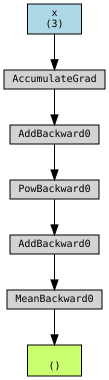

In [20]:
from torchviz import make_dot

dot = make_dot(y, params={"x": x})

dot

### Ejercicios propuestos

1) Prueba a realizar el cálculo analítico de la función anterior en papel y a calcular las derivadas parciales. ¿Obtienes el mismo resultado?

2) Comprueba los tipos de los tensores, ¿qué sucede si cambias la creación del tensor por `t1 = torch.tensor([2,3], requires_grad=True)`?. ¿Por qué?

3) Implementa la siguiente función en PyTorch $$y=\dfrac{\sum_{i=1}^n{sin(x_i)×exp(x_i)+\dfrac{1}{x_i+2}}}{n}$$.
   - Dibuja su grafo computacional.
   - Crea un tensor con números desde 1 hasta 5.
   - Evalúa esta función para este tensor de entrada.
   - Calcula el gradiente correspondiente para cada una de estas entradas $\dfrac{\partial{y}}{\partial{x_i}}$.

4) Dado el siguiente dataset:

   | x  | y |
   | -------- | ------- |
   | 0  | 0 |
   | 1  | 2 |
   | 2  | 4 |
   | 3  | 6  |
   | 4    | 8 |
   | 5    | 10 |

Crea el código necesario para entrenar un perceptrón usando PyTorch.
 - Entréna tu perceptrón durante 1000 épocas con un learning rate de 0.01.
 - Imprime el error cada 100 épocas.
 - Una vez entrenado el perceptrón, predice la y para un valor x=6.

## Tercera Parte

En esta tercera parte vamos a crear una pequeña red neuronal con PyTorch para resolver nuestro primer problema de clasificación. Como veremos, trabajaremos con tensores pero también con modulos ya programados en PyTorch que representan capas de una red neuronal. La clase básica para hacer esto es torch.nn.Module. Vamos a ir haciendolo paso por paso.



#### Generación y preparación del dataset
Lo primero vamos a generar unos datos. Queremos generar un dataset con cierta complejidad, que no sea **linearmente separable**. Como hemos visto en teoría un buen ejemplo de esto es el problema **XOR**.

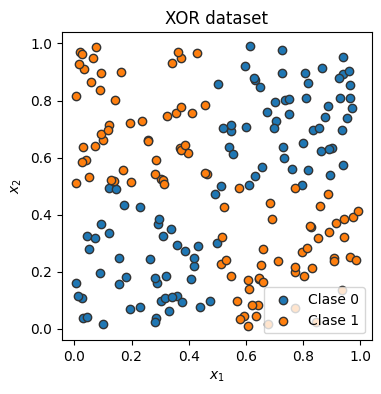

In [23]:
#Necesario para que funcionen los plots en google colab
%matplotlib inline

np.random.seed(42)
torch.manual_seed(2032)

# Función para generar un dataset estilo XOR
def generate_xor_dataset(n_samples):

    X = np.random.rand(n_samples, 2)
    y = np.logical_xor(X[:, 0] > 0.5, X[:, 1] > 0.5)
    y = np.where(y, 1, 0)
    return X, y

# Generar dataset
X, y = generate_xor_dataset(n_samples=200)

# Plot el dataset
data_0 = X[y == 0]
data_1 = X[y == 1]

plt.figure(figsize=(4, 4))
plt.scatter(data_0[:, 0], data_0[:, 1], edgecolor="#333", label="Clase 0")
plt.scatter(data_1[:, 0], data_1[:, 1], edgecolor="#333", label="Clase 1")
plt.title("XOR dataset")
plt.ylabel(r"$x_2$")
plt.xlabel(r"$x_1$")
plt.legend()
plt.show()


Ten en cuenta que en este caso he decidido generar los datos y visualizarlos usando Numpy, pero como ya sabemos podemos convertirlos de manera muy sencilla a tensores.

In [24]:
X = torch.from_numpy(np.float32(X))
y = torch.from_numpy(y)
print("Dimension X", X.shape)
print("Dimension y", y.shape)


Dimension X torch.Size([200, 2])
Dimension y torch.Size([200])


PyTorch necesita que los datos estén en una clase que herede de **torch.data.Dataset**. Aquí tenemos muchas variantes que iremos viendo a lo largo del curso. Si tenemos ya los datos en formato numérico en un par de tensores (como es el caso), podemos usar TensorDataset. Para imágenes existen clases ya programadas. Incluso para datasets muy utilizados como ImageNet, podemos utilizar la clase **torchvision.datasets.ImageNet**. Todas ellas heredan de la misma clase e implementan los mismos métodos.

In [25]:
from torch.utils.data import TensorDataset

dataset = TensorDataset(X,y)
print("Número de ejemplos: ",len(dataset)) #Tenemos 200 ejemplos

Número de ejemplos:  200


Puedes imaginar un Dataset en PyTorch simplemente como una clase que es capaz de devolver un único ejemplo, tenga la forma que tenga:

In [26]:
dataset[0]

(tensor([0.3745, 0.9507]), tensor(1))

Aquí hemos obtenido el primer ejemplo, que en este caso pertenece a la clase positiva.

Cuando entrenamos redes neuronales, generalmente los datos se pasan en lotes. Para ello, debemos de ser capaces de cargar múltiples ejemplos de una vez en un mini-batch. La clase que se encarga de hacer esto de manera eficiente en Pyorch es el **Dataloader**, que siempre recibe como parámetro un dataset del que cargar los datos.

In [27]:
from torch.utils.data import DataLoader

data_loader = DataLoader(dataset, batch_size=8, shuffle=True) #suffle true indica que los ejemplos vienen en orden aleatorio

Podemos ver por ejemplo como el DataLoader devolvería ejemplos de 8 en 8.

In [28]:
data_inputs, data_labels = next(iter(data_loader))
print("Mini-batch X", data_inputs.shape, "\n", data_inputs)
print("Mini-batch y", data_labels.shape, "\n", data_labels)

Mini-batch X torch.Size([8, 2]) 
 tensor([[0.6229, 0.0853],
        [0.1182, 0.6967],
        [0.1560, 0.1560],
        [0.9367, 0.1375],
        [0.9656, 0.8084],
        [0.5467, 0.1849],
        [0.6334, 0.8715],
        [0.7122, 0.2372]])
Mini-batch y torch.Size([8]) 
 tensor([1, 1, 0, 1, 0, 1, 0, 1])


#### Definiendo la arquitectura de la red
Una vez que tenemos los datos preparados, vamos a definir la arquitectura de la red. En este caso vamos a optar por una red totalmente conectada, simple, con una capa oculta y una función de activación ReLU en la capa oculta y sigmoide en la de salida

In [29]:
import torch.nn as nn

class MLP(nn.Module):
    def __init__(self, num_inputs, num_hidden, num_outputs):
        super().__init__()
        # Inicializar los módulos para la red
        self.linear1 = nn.Linear(num_inputs, num_hidden)
        self.act_fn_hidden = nn.ReLU()
        self.linear2 = nn.Linear(num_hidden, num_outputs)
        self.act_fn_out = nn.Sigmoid()

    def forward(self, x):
        # Definir como se hace una pasada hacia delante
        x = self.linear1(x)
        x = self.act_fn_hidden(x)
        x = self.linear2(x)
        x = self.act_fn_out(x)
        return x

model = MLP(num_inputs=2, num_hidden=10, num_outputs=1)
# Imprimir el modelo
print(model)


MLP(
  (linear1): Linear(in_features=2, out_features=10, bias=True)
  (act_fn_hidden): ReLU()
  (linear2): Linear(in_features=10, out_features=1, bias=True)
  (act_fn_out): Sigmoid()
)


Podemos ver la estructura del modelo imprimiéndolo. También sería posible iterar sobre los parámetros aprendibles de la red:

In [30]:
for name, param in model.named_parameters():
    print(f"Parámetro {name}, forma {param.shape}")

Parámetro linear1.weight, forma torch.Size([10, 2])
Parámetro linear1.bias, forma torch.Size([10])
Parámetro linear2.weight, forma torch.Size([1, 10])
Parámetro linear2.bias, forma torch.Size([1])


#### Función de pérdida
Como ya sabemos, elegir la función de pérdida es crítico. En este caso es un problema de clasificación binario así que utilizaremos la función BCE (Binary Cross Entropy Loss). Esta función ya viene programa por defecto en PyTorch.

In [31]:
loss = nn.BCELoss()

#### Optimizador
Como ya sabemos, también debemos elegir un optimizador. Utilizaremos el más básico que es Stochastic-Gradient Descent. Tendremos que escoger también el **learning rate**.

In [32]:
optimizer = torch.optim.SGD(model.parameters(), lr=0.05)

#### Entrenando la red
Vamos ahora a codificar el bucle general de entrenamiento de una red. Aquí lo que haremos será iterar sobre el dataloader, ir cargando mini-batches y haciendo una pasada adelante seguida de una pasada hacia atrás para calcular los gradientes. Por último, con la ayuda del optimizador, actualizaremos los pesos de la red para seguir iterando de esta manera un número de épocas determinado.

In [33]:
# Instala pip install ipywidgets tqdm si es necesario


from tqdm.notebook import tqdm

def train_model(model, optimizer, data_loader, loss_module, num_epochs=1000):
    # Ponemos el modelo en modo train
    model.train()

    # Training loop
    pbar = tqdm(range(num_epochs))
    for epoch in pbar:
        epoch_loss = 0
        for data_inputs, data_labels in data_loader:
            #Hacer una pasada hacia delante
            preds = model(data_inputs)
            # Output es [Batch size, 1], pero queremos [Batch size]
            preds = preds.squeeze(dim=1)
            #Calcular el valor de la función de pérdida para este mini-batch
            loss = loss_module(preds, data_labels.float())
            #Acumular el error (solo para luego mostrarlo)
            epoch_loss += loss.item()
            #Reiniciar los gradientes
            optimizer.zero_grad()
            #Pasada hacia atrás
            loss.backward()
            #Actualizar los parámetros
            optimizer.step()
        #Imprimir el error cada 50 épocas
        if epoch%50==0:
            pbar.set_description("Loss %0.2f" % epoch_loss)

train_model(model, optimizer, data_loader, loss)

  0%|          | 0/1000 [00:00<?, ?it/s]

#### Visualización del modelo

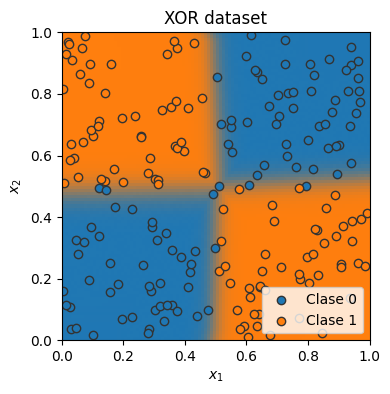

In [34]:
from matplotlib.colors import to_rgba

def visualize_classification(model, data, label):
    data_0 = data[label == 0]
    data_1 = data[label == 1]

    plt.figure(figsize=(4, 4))
    plt.scatter(data_0[:, 0], data_0[:, 1], edgecolor="#333", label="Clase 0")
    plt.scatter(data_1[:, 0], data_1[:, 1], edgecolor="#333", label="Clase 1")
    plt.title("XOR dataset")
    plt.ylabel(r"$x_2$")
    plt.xlabel(r"$x_1$")
    plt.legend()

    c0 = to_rgba("C0")
    c1 = to_rgba("C1")
    x = np.arange(0, 1, step=0.01)
    xx1, xx2 = np.meshgrid(x, x)
    model_inputs = np.stack([xx1.flatten(), xx2.flatten()], axis=-1)
    #Modelo en modo evaluación (inferencia)
    model.eval()
    with torch.no_grad():
        preds = model(torch.from_numpy(np.float32(model_inputs))).reshape(xx1.shape).cpu().detach().numpy()
    output_image = (1 - preds)[:, :, np.newaxis] * c0 + preds[:, :, np.newaxis] * c1

    plt.imshow(output_image, origin="lower", extent=(0, 1, 0, 1))
    plt.grid(False)

visualize_classification(model, X.cpu().numpy(), y.cpu().numpy())

### Ejercicios propuestos

1. Prueba a cambiar el número de épocas del entrenamiento. ¿Qué sucede?
2. Prueba a quitar la función de activación.
3. Prueba a cambiar el número de neuronas en la capa oculta.
4. Modifica el código para que se pueda entrenar este modelo en la GPU. Para ello deberás de mover el modelo a la gpu (cuda:0) así como los tensores necesarios (pruebalo en google colab)
5. Calcula el acierto del modelo e imprímelo.
6. Genera un conjunto de test con las mismas características y evalúalo con este mismo modelo. ¿Qué error obtienes?

## Cuarta Parte

### Datasets y Dataloaders

Las clases `torch.utils.data.DataSet` y `torch.utils.data.DataLoader` son las clases básicas que usamos en PyTorch para la carga eficiente de datos. Manejarlas bien por tanto es crítico para llevar a cabo el entrenamiento de una red profunda con éxito. Estas dos clases tienen objetivos diferentes:
- La clase `DataSet` abstrae el concepto de conjunto de datos, almacenando los ejemplos y su etiqueta correspondiente y proveyendo métodos para la obtención de uno de estos ejemplos.
- La clase `DataLoader` encapsula a un `DataSet` y permite el acceso eficiente a lotes de ejemplos.

Es importante destacar que estas clases permiten el acceso a datasets ya creados como por ejemplo MNIST o ImageNet, así como a datasets con nuestros datos. Ten en cuenta que no solo serán datasets con imágenes sino que tendremos diferentes subclases para otros tipos de datasets.


### Carga de un DataSet
En este caso vamos a cargar el conocido dataset MNIST. Este dataset tiene 60.000 ejemplos de entrenamiento y 10.000 ejemplos de test.

In [35]:
from torch.utils.data import Dataset, random_split
from torchvision import datasets
from torchvision.transforms import ToTensor
import matplotlib.pyplot as plt


training_data = datasets.MNIST(root="data",train=True,download=True,transform=ToTensor())
test_data = datasets.MNIST(root="data", train=False, download=True, transform=ToTensor())

print("Datos de entrenamiento:")
print(training_data, end='\n\n')
print("Datos de test:")
print(test_data, end='\n\n')

100%|██████████| 9.91M/9.91M [00:01<00:00, 4.96MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 131kB/s]
100%|██████████| 1.65M/1.65M [00:01<00:00, 1.26MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 12.7MB/s]

Datos de entrenamiento:
Dataset MNIST
    Number of datapoints: 60000
    Root location: data
    Split: Train
    StandardTransform
Transform: ToTensor()

Datos de test:
Dataset MNIST
    Number of datapoints: 10000
    Root location: data
    Split: Test
    StandardTransform
Transform: ToTensor()




Los parámetros usados son los siguientes:
- **root**. ruta donde se almacenará el dataset en nuestro dispositivo de almacenamiento.
- **train**. Especifica si queremos el conjunto de entrenamiento o el de test.
- **download**. Si le pasamos true, descarga los datos de internet si no están disponibles en el directorio root.
- **transform**. Transforma los ejemplos antes de devolverlos. Es útil para hacer **aumento de datos** que veremos en otra práctica. En este caso lo usamos para convertir las imágenes a un tensor que nos sirva para nuestra red neuronal.



### Visualizando el dataset
Vamos ahora a visualizar algunas imágenes aleatoriamente. Ten en cuenta que para realizar esto, podemos acceder a cada elemento del dataset como si fuese un simple array o una lista `training_data[i]`. Este código devuelve el ejemplo i-ésimo así como la etiqueta del mismo.

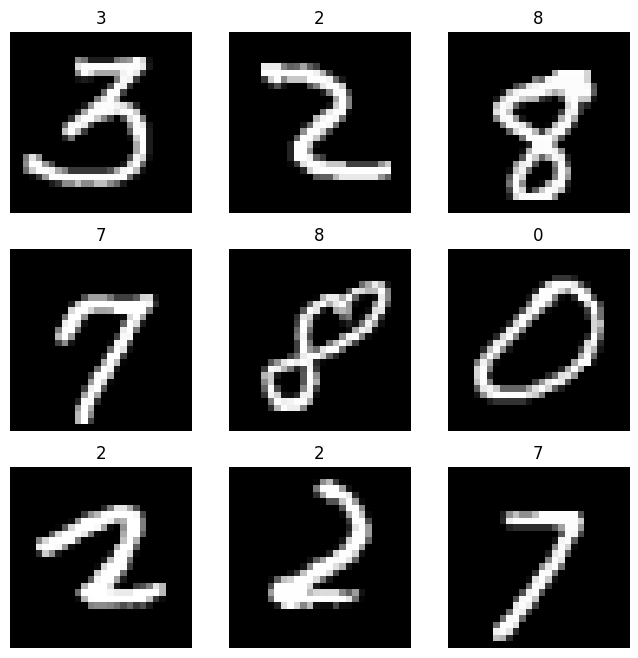

In [36]:
figure = plt.figure(figsize=(8, 8))
cols, rows = 3, 3
for i in range(1, cols * rows + 1):
    sample_idx = torch.randint(len(training_data), size=(1,)).item()
    img, label = training_data[sample_idx]
    figure.add_subplot(rows, cols, i)
    plt.title(label)
    plt.axis("off")
    plt.imshow(img.squeeze(), cmap="gray")
plt.show()

### Dividiendo el DataSet
Es común que queramos dividir el dataset de entrenamiento para separar una parte para **validación**. PyTorch tiene una función muy útil para ello que permite hacerlo rápidamente:

In [37]:
train_dataset, val_dataset = random_split(training_data, (50000, 10000))

Los objetivos devueltos por **random_split** son de tipo `Subset`. A efectos prácticos, esta clase funciona igual que DataSet y es capaz de devolvernos ejemplos individuales directamente.

### Otros tipos de DataSets (TensorDataSet)
Supongamos ahora que nuestros datos no son imágenes. Imaginemos que tenemos datos de tipo tabular. En este caso la clase que hay que utilizar es `TensorDataSet` (que extiende de `DataSet`). Esta clase recibe en su constructor un número de tensores (típicamente dos, uno para las `X` y otro para las `y`). Veamos su uso:

In [38]:
from torch.utils.data import TensorDataset

#Generar datos para nuestro dataset.
X = torch.rand((100,2))
y = torch.randint(low=0,high=2,size=(100,))

custom_training_data = TensorDataset(X,y)
print("Imprimiento el primer ejemplo de nuestro dataset bidimensional:")
print(custom_training_data[0])

Imprimiento el primer ejemplo de nuestro dataset bidimensional:
(tensor([0.5760, 0.0207]), tensor(0))


### Creando nuestra propia subclase de DataSet
Existen circunstancias en las que es adecuado crear nuestra subclase de la clase `DataSet`. Por ejemplo, esto ocurre cuando queremos cargar imágenes de un directorio. Un ejemplo de este uso sería el siguiente:

In [39]:
import os
import pandas as pd
from torchvision.io import read_image

class CustomImageDataset(Dataset):
    def __init__(self, annotations_file, img_dir, transform=None):
        self.img_labels = pd.read_csv(annotations_file)
        self.img_dir = img_dir
        self.transform = transform

    def __len__(self):
        return len(self.img_labels)

    def __getitem__(self, idx):
        img_path = os.path.join(self.img_dir, self.img_labels.iloc[idx, 0])
        image = read_image(img_path)
        label = torch.tensor(self.img_labels.iloc[idx, 1])
        if self.transform:
            image = self.transform(image)
        return image, label

Para extender a DataSet siempre tendremos que implementar:
- El **constructor**, donde podemos pasarle todos los atributos que necesitemos.
- El método `__len__`, que devuelve el tamaño del dataset.
- El método `__getitem__`, que devuelve el elemento i-ésimo del dataset.

Una alternativa a la clase anterior, si se necesita cargar **imágenes que están distribuidas en clases por directorios** es utilizar la clase
`torchvision.datasets.ImageFolder`. La etiqueta de cada ejemplo se inferirá directamente de nombre del directorio correspondiente.

### La clase DataLoader
Como has visto hasta ahora, un DataSet es capaz de devolver un ejemplo de cada vez. Típicamente cuando entrenamos una red neuronal profunda queremos pasarle a la red **mini-batches** de ejemplos. Además, necesitamos que la carga sea rápida para que el acceso a los datos no sea un cuello de botella en nuestro pipeline de entrenamiento. Aquí es donde la clase `DataLoader` es útil. Provee la funcionalidad necesaria para acceder a batches de ejemplos así como hacerlo en paralelo utilizando las capacidades de multiproceso de nuestra máquina.

Dimensiones del batch (X): torch.Size([64, 1, 28, 28])
Dimensiones del batch (y): torch.Size([64])


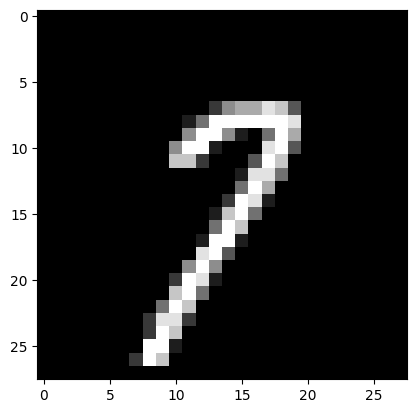

Label: 7


In [40]:
from torch.utils.data import DataLoader

train_dataloader = DataLoader(training_data, batch_size=64, shuffle=True, num_workers=2)
test_dataloader = DataLoader(test_data, batch_size=64, shuffle=True, num_workers=2)

# Display image and label.
train_features, train_labels = next(iter(train_dataloader))
print(f"Dimensiones del batch (X): {train_features.size()}")
print(f"Dimensiones del batch (y): {train_labels.size()}")
img = train_features[0].squeeze()
label = train_labels[0]
plt.imshow(img, cmap="gray")
plt.show()
print(f"Label: {label}")

Como puedes ver en el ejemplo anterior, estamos cargando 64 imágenes al mismo tiempo y el DataLoader nos devuelve dos tensores. El primero tiene un tamaño de **64x1x28x28**, que corresponde a 64 imagenes con un solo canal y unas dimensiones de 28x28 pixeles. Las etiquetas vendrán en un tensor unidimensional con un tamaño de 64.

### Orden de carga de los ejemplos

Como puedes ver en el ejemplo anterior, los ejemplos se cargan secuencialmente (se utiliza el sampler torch.utils.data.SequentialSampler). Con el atributo **shuffle** controlamos si queremos que los ejemplos se desordenen antes de ser devueltos (en este caso se utilizaría torch.utils.data.RandomSampler). Pero, gracias al DataLoader, podemos controlar de manera más fina el orden de los ejemplos. Para ello necesitamos usar el parámetro **sampler** y **batch_sampler** del DataLoader.

### Ejercicios propuestos
1. Modifica la clase CustomImageDataset para que no haga falta pasarle las etiquetas de los ejemplos y las coja del subdirectorio en el que se encuentre la imagen. Puedes probar tu Dataset con el conjunto de datos [Stanford Dogs Dataset](http://vision.stanford.edu/aditya86/ImageNetDogs/). Para ello descarga el archivo images.tar y verás que las imágenes de cada categoría se encuentran en un subdirectorio independiente. Para resolver el ejercicio no necesitas el archivo de anotaciones.
2. Utiliza la clase **Subset** de PyTorch para dividir el conjunto del mnist en train y validación. Dejaremos para validación el 20% de los ejemplos aleatoriamente. Usa una semilla para que siempre sean los mismos.
3. Crea un subconjunto del mnist que solo tenga unos y doses (utiliza Subset(dataset, indices), pasando una lista de indices que quieres incluir en el nuevo dataset).
3. Navega en la documentación de PyTorch para encontrar la clase torch.utils.data.WeightedRandomSampler. Utiliza este sampler para crear un data loader que sea capaz de devolver doses con el doble de probabilidad que unos.

## QUINTA PARTE

En este notebook vamos a utilizar los conocimientos aprendidos en los notebooks anteriores para realizar un entrenamiento más avanzando. En particular aprenderemos lo siguiente:
- Carga de un dataset.
- Particionado de los datos.
- Creación de los DataLoaders.
- Bucle de entrenamiento, validación y early stopping.
- Salvar el modelo y checkpoints intermedios. Carga de modelos.
- Inferencia.

Trabajaremos en este caso con el conjunto FashionMNIST, un conjunto con **10 clases**, 60.000 ejemplos de entrenamiento y 10.000 ejemplos para test.

### Carga de los datos
Procederemos igual que en la práctica anterior:

In [41]:
training_data = datasets.FashionMNIST(root="data",train=True,download=True,transform=ToTensor())
test_data = datasets.FashionMNIST(root="data", train=False, download=True, transform=ToTensor())

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Utilizando dispositivo: %s" % device)

print("Datos de entrenamiento:")
print(training_data, end='\n\n')
print("Datos de test:")
print(test_data, end='\n\n')

# Separación de un conjunto de validación
training_data, validation_data = random_split(training_data,(50000,10000))

100%|██████████| 26.4M/26.4M [00:03<00:00, 8.78MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 168kB/s]
100%|██████████| 4.42M/4.42M [00:01<00:00, 3.09MB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 12.3MB/s]

Utilizando dispositivo: cuda
Datos de entrenamiento:
Dataset FashionMNIST
    Number of datapoints: 60000
    Root location: data
    Split: Train
    StandardTransform
Transform: ToTensor()

Datos de test:
Dataset FashionMNIST
    Number of datapoints: 10000
    Root location: data
    Split: Test
    StandardTransform
Transform: ToTensor()



### Visualización de los datos

Visualizamos algunos datos para ver como son las imágenes:

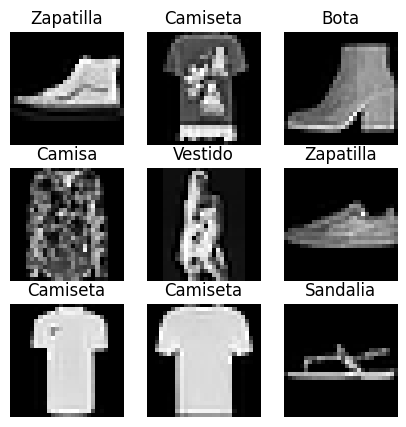

In [42]:
labels_map = {
    0: "Camiseta",
    1: "Pantalón",
    2: "Jersey",
    3: "Vestido",
    4: "Abrigo",
    5: "Sandalia",
    6: "Camisa",
    7: "Zapatilla",
    8: "Bolso",
    9: "Bota",
}

figure = plt.figure(figsize=(5, 5))
cols, rows = 3, 3
for i in range(1, cols * rows + 1):
    sample_idx = torch.randint(len(training_data), size=(1,)).item()
    img, label = training_data[sample_idx]
    figure.add_subplot(rows, cols, i)
    plt.title(labels_map[label])
    plt.axis("off")
    plt.imshow(img.squeeze(), cmap="gray")
plt.show()

### Creación de los DataLoaders

In [43]:
from torch.utils.data import DataLoader

train_dataloader = DataLoader(training_data, batch_size=64, shuffle=True, num_workers=2)
val_dataloader = DataLoader(validation_data, batch_size=64, shuffle=True, num_workers=2)
test_dataloader = DataLoader(test_data, batch_size=64, shuffle=False, num_workers=2)

### Definición de la red
En este caso utilizaremos de nuevo una red totalmente conectada, aunque sería más adecuado utilizar una red convolucional para mejorar el rendimiento del sistema.

In [44]:
import torch.nn.functional as F

class Net(nn.Module):
    def __init__(self, dropout=0.2, linear_sizes = (50, 50, 10)):
        super(Net, self).__init__()
        self.layers = nn.Sequential()
        previous_size = 28*28 # la entrada tienen que coincidir con el número de pixeles en la imagen
        for i, linear_size in enumerate(linear_sizes):
            self.layers.append(nn.Linear(previous_size, linear_size))
            if i != len(linear_sizes)-1:
                # Añadir dropout y función de activación salvo en la última capa de salida
                self.layers.append(nn.ReLU())
                self.layers.append(nn.Dropout(dropout))
            previous_size = linear_size

    def forward(self, x):
        x = x.view(-1, 28*28)
        return self.layers(x)

### Creación de los bucles de validación y entrenamiento
Aquí vamos a crear los bucles de entrenamiento de la red. En primer lugar creamos el bucle de validación, que se encarga de calcular la función de pérdida en el conjunto de validación. Ten en cuenta que en este caso no necesitamos actualizar los gradientes de la red, por tanto utilizamos `torch.no_grad()` y ponemos la red en modo evaluación con el método `eval()`.

In [45]:
def validation(model, loss_module, val_dataloader):
    val_loss=0
    with torch.no_grad():
        model.eval()
        for data_inputs, data_labels in val_dataloader:
            data_inputs, data_labels = data_inputs.to(device), data_labels.to(device)
            logits = model(data_inputs)
            val_loss += loss_module(logits, data_labels)
        return val_loss/ len(val_dataloader)


En el bucle de entrenamiento, después de acabar cada época, calculamos el error de validación y lo imprimimos. Este error también se usa para realizar la **parada temprana**, cuando el error de validación deje de decrecer. También aprovechamos para salvar el mejor modelo hasta el momento. Para ello utilizamos la instrucción: `torch.save(model.state_dict(), 'best_model.pth')`.

In [46]:
from tqdm.notebook import tqdm

def train_model(model, optimizer, train_dataloader, val_dataloader, loss_module, patience=3, max_epochs=20):

    min_loss = float('inf')
    no_improvement = 0

    # Bucle de entrenamiento
    pbar = tqdm(range(max_epochs))
    for epoch in pbar:
        # Poner el modelo en modo entrenamiento
        model.train()
        epoch_loss = 0
        for data_inputs, data_labels in train_dataloader:
            #Hacer una pasada hacia delante
            data_inputs = data_inputs.to(device)
            data_labels = data_labels.to(device)
            preds = model(data_inputs)
            # La salida es [Batch size, 1], queremos [Batch size]
            preds = preds.squeeze(dim=1)
            #Calcular el valor de la función de pérdida para este mini-batch
            loss = loss_module(preds, data_labels)
            #Acumular el error (solo para luego mostrarlo)
            epoch_loss += loss.item()
            #Reiniciar los gradientes
            optimizer.zero_grad()
            #Pasada hacia atrás
            loss.backward()
            #Actualizar los parámetros
            optimizer.step()
        val_loss = validation(model, loss_module, val_dataloader)
        if val_loss < min_loss:
            min_loss = val_loss
            no_improvement=0
            torch.save(model.state_dict(), 'best_model.pth')
        else:
            no_improvement += 1

        pbar.set_description("Training Loss %0.2f. Validation Loss %0.2f. Patience: %d/%d" % (epoch_loss/len(train_dataloader), val_loss, no_improvement, patience))
        if no_improvement>=patience:
            print("No hay mejora por %d épocas. Parada Temprana!!" % patience)
            break



### Entrenando la red
Una vez que tenemos todo preparado estamos en situación de entrenar la red. Para ello inicializamos el modelo y lanzamos el entrenamiento. Hay que tener en cuenta que el mejor modelo quedará salvado en el archivo `best_model.pth`, que luego podremos utilizar para inferencia.

In [47]:
model = Net(dropout=0.2, linear_sizes=(50,10))
model = model.to(device)
optimizer = torch.optim.SGD(model.parameters(), lr=0.05)
loss = nn.CrossEntropyLoss()
train_model(model, optimizer, train_dataloader, val_dataloader, loss)

  0%|          | 0/20 [00:00<?, ?it/s]

No hay mejora por 3 épocas. Parada Temprana!!


### Inferencia
Una vez que tenemos entrenado el modelo es momento de evaluar el conjunto de test con él y analizar las métricas que estemos interesados.

In [48]:
# Cargamos el mejor modelo
model.load_state_dict(torch.load('best_model.pth'))

correct_predictions = 0
total_predictions = 0

with torch.no_grad():
    model.eval()
    for data_inputs, data_labels in test_dataloader:
        data_inputs, data_labels = data_inputs.to(device), data_labels.to(device)
        logits = model(data_inputs)
        _, predicted_classes = torch.max(logits, 1)  # Get the predicted classes
        correct_predictions += (predicted_classes == data_labels).sum().item()
        total_predictions += data_labels.size(0)
    accuracy = correct_predictions / total_predictions
    print("Accuracy: {:.2%}".format(accuracy))


Accuracy: 85.56%


### Ejercicios
1. Modifica el código para que tanto en el entrenamiento como en validación se calcule (y se imprima en la barra de progreso) también el acierto del modelo y no solo el cross entropy.
2. Modifica los hiperparámetros del entrenamiento. ¿Hasta donde eres capaz de llevar el acierto en test?
3. Modifica el número de capas lineales y su tamaño. ¿Puedes mejorar el acierto de la red?
4. Prueba a cargar el conjunto de entrenamiento completo en la GPU para no tener que mover cada batch. ¿Notas alguna diferencia en velocidad? Pruebalo en Google Colab.
5. Modifica el código para salvar en cada época la loss de entrenamiento y de validación y al final del entrenamiento, pinta una gráfica para ver como han progresado ambas métricas.